## Causal Price Effect  

### 1. Causal Question  

    1. What is the causal impact of price competitiveness on Buy Box ownership?  
    2. What is the effect of being the lowest priced seller on the probability of winning the Buy Box?  


In [1]:
import pandas as pd 
import numpy as np  
from pathlib import Path
import matplotlib.pyplot as plt 
import seaborn as sns 
import os 
import statsmodels.api as sm 
from src.utils.io import save_df

# load data into dataframe

df = pd.read_csv("data/synthetic/marketplace_panel.csv")

df.head()
#PROJECT_ROOT = Path.cwd().resolve()
#print("Project root:", PROJECT_ROOT)

,day,asin,seller_id,seller_rating,fulfillment_type,shipping_days,product_cost,target_price,base_demand,price,...,price_gap_to_lowest,buy_box_probability,buy_box_winner,market_demand_units,units_sold,revenue,amazon_referral_fee,fulfillment_cost,contribution_profit_per_unit,contribution_profit
0,1,A0001,S032,88.5,FBA,2,82.06,120.02,40,113.24,...,0.00,0.6786,0,49,3,339.72,16.99,5.90,8.29,24.87
1,1,A0001,S028,92.1,FBM,5,82.06,120.02,40,113.80,...,0.56,0.0874,1,49,39,4438.20,17.07,6.25,8.42,328.38
2,1,A0001,S018,86.2,FBM,3,82.06,120.02,40,115.80,...,2.56,0.0348,0,49,2,231.60,17.37,5.55,10.82,21.64
3,1,A0001,S021,91.8,FBA,2,82.06,120.02,40,115.87,...,2.63,0.1474,0,49,4,463.48,17.38,5.90,10.53,42.12
4,1,A0001,S012,93.1,FBA,2,82.06,120.02,40,118.65,...,5.41,0.0350,0,49,0,0.00,17.80,5.90,12.89,0.00


In [22]:
# defining treatment and outcome

df['is_lowest_price'] = (df["price_rank"] == 1).astype(int)
df['is_fba'] = (df['fulfillment_type']=='FBA').astype(int)

treatment = 'is_lowest_price' # binary, this is a discrete jump effect, not slope as in price gap to lowest (notebook 4)
outcome = 'buy_box_winner'

#saving modified df
save_df(df, 'data/processed/marketplace_modeling_dataset', 'csv', False)

Saved to: data/processed/marketplace_modeling_dataset.csv


In [3]:
# naive estimate

naive = df.groupby(treatment)[outcome].mean()
print(naive)

is_lowest_price
0    0.081753
1    0.626580
Name: buy_box_winner, dtype: float64


### Naive Estimate  

    The Naive Estimate suggest having the lowest price significatly increases the probability of winning the Buy Box. However, this estimate may be biased because sellers who are lowest priced may also differ in fulfillment type, shipping speed, or seller quality.  

    The Naive Estimate is the probability (62%) of winning the buy box WITHOUT adjusting for other features. This estimate is biased.  

---



## Regression Adjustment  

Pricing decisions are not random.  

Sellers with faster shipping, better ratings, or FBA may systematically choose different pricing strategies  
These factors influence both:  

    1. the likelihood of being the lowest priced  
    2. the probability of winning the Buy Box  

Failing to adjust for these variables leads to biased estimates.  


In [4]:
print(Path("data/processed/aug_reg_results.csv").resolve())

/Users/scottbelarmino/ds_decision_science_exp_repo/project_3_amazon_buy_box_marketplace/data/processed/aug_reg_results.csv


In [5]:
## definie features to control  

features = ['is_lowest_price', 'shipping_days','seller_rating','is_fba']

X = sm.add_constant(df[features])
y = df[outcome]

model = sm.Logit(y, X)
results = model.fit()

print(results.summary())  

Optimization terminated successfully.
         Current function value: 0.329431
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:         buy_box_winner   No. Observations:                74970
Model:                          Logit   Df Residuals:                    74965
Method:                           MLE   Df Model:                            4
Date:                Fri, 20 Mar 2026   Pseudo R-squ.:                  0.3013
Time:                        13:07:08   Log-Likelihood:                -24697.
converged:                       True   LL-Null:                       -35349.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -6.8277      0.274    -24.955      0.000      -7.364      -6.291
is_lowest_pric

In [6]:
coef = results.params['is_lowest_price']
odds_ratio = np.exp(coef)

print(f'is lowest price coefficient: {coef}, odds ratio: {odds_ratio}')

coef_sd = results.params['shipping_days']
odds_ratio_sd = np.exp(coef_sd)

print(f'shipping days coefficient: {coef_sd}, odds ratio: {odds_ratio_sd}')

coef_sr = results.params['seller_rating']
odds_ratio_sr = np.exp(coef_sr)

print(f'seller rating coefficient: {coef_sr}, odds ratio: {odds_ratio_sr}')

coef_f = results.params['is_fba']
odds_ratio_f = np.exp(coef_f)

print(f'is fba coefficient: {coef_f}, odds ratio: {odds_ratio_f}')

is lowest price coefficient: 3.1606296979623014, odds ratio: 23.58544295937666
shipping days coefficient: -0.2841612929279341, odds ratio: 0.75264523856126
seller rating coefficient: 0.04792337638991126, odds ratio: 1.0490902671611153
is fba coefficient: 0.7268492220118367, odds ratio: 2.068552778642175


### What this model is doing  

    "What happens to Buy Box probability if a seller becomes the LOWEST PRICE, holding everything else constant (controls = shipping, rating, FBA)"  

is_lowest_price coefficient is 3.1606 (logit odds) or an odds ratio of 23.6 when converted.  

    "Being the lowest priced seller increases your odds of winning the Buy Box by 23x, after controlling for shipping, rating, and FBA"  
    "Having the lowest price is a massive advantage"  

    1. Lowest price sellers have 23x odds of winning the Buy Box (lowest price is binary)  
    2. Each extra day of shipping reduces the odds of winning by 25% (shipping days is continuous)  
    3. Increasing the seller rating provides a little odds improvement of 5%  (seller rating is continuous)
    4. FBA sellers have 2x odds of winning the Buy Box (fba is binary)  

If we were to compare this to the Naive Estimate, we would need to convert the 0.62 probability of winning the buy box without controlling other variables (i.e., Lowest price is EVERYTHING).  

```
# buy box win
p = 0.62
odds = 0.62 / (1 - 0.62) = 1.63

# buy box loss  
p ≈ 0.01
odds = 0.01 / 0.99 ≈ 0.0101

Naive Odds Ratio  
1.63 / 0.0101 ≈ 161x  
```  

    -The Naive Odds Ratio suggests having the lowest price will improve the odds by 161x (biased from other features)  
    -The Adjusted Odds Ratio, with all else being equal, the lowest price will improve the odds by 23x (cleaner estimate of price effiect)  

### "The naive estimate suggested a ~160x increase in odds of winning the Buy Box when being the lowest priced seller. After adjusting for fulfillment, shipping speed, and seller quality, this effect decreases to ~23x, indicating that a substantial portion of the naive relationship was driven by confounding factors.  

    Naive: What you SEE (cheapest sellers win a lot -> it must be the price!)  
    Adjusted: What is True given assumptions: Reality - sellers with faster shipping, better ratings, and are FBA impact the buy box odds.


### Inverse Propensity Weighting  

To add additional support of understanding the confounding variables impact, we will use IPW and make the data look like Treatment was randomly assigned. We will upwieght underrepresented cases and downweight overrepresented cases.  

    If FBA sellers are often lowest price, then:  
    - FBA + NOT lowest price => rare, and will be given more weight  
    - FAB + lowest price => common, and will be given less weight  

    Propensity Score is the probability of receiving treatment given observed characteristics  
    - "I corrected for selection bias BEFORE estimating the effect" is much STRONGER than  
    - "I just controlled for variables in a regression"  

Balancing Propenisty Scores  
    - Lowest price sellers are NOT comparable to others (before IPW)
      - differences in shipping days, seller rating, and fba  
    - Treated ~ Control, they are more comparable (after IPW)  
      - IPW corrects or reduces these differences so we can compare treatment and ccontrol fairly

In [7]:
# Estimating Propensity Scores  
# "What is the probability of being lowest price given features?"
# P(is_lowest_price | shipping, rating, FBA)

import statsmodels.api as sm

ps_features = ["shipping_days", "seller_rating", "is_fba"]

X_ps = sm.add_constant(df[ps_features])
y_ps = df["is_lowest_price"]

ps_model = sm.Logit(y_ps, X_ps).fit()

df["propensity_score"] = ps_model.predict(X_ps)

Optimization terminated successfully.
         Current function value: 0.470958
         Iterations 6


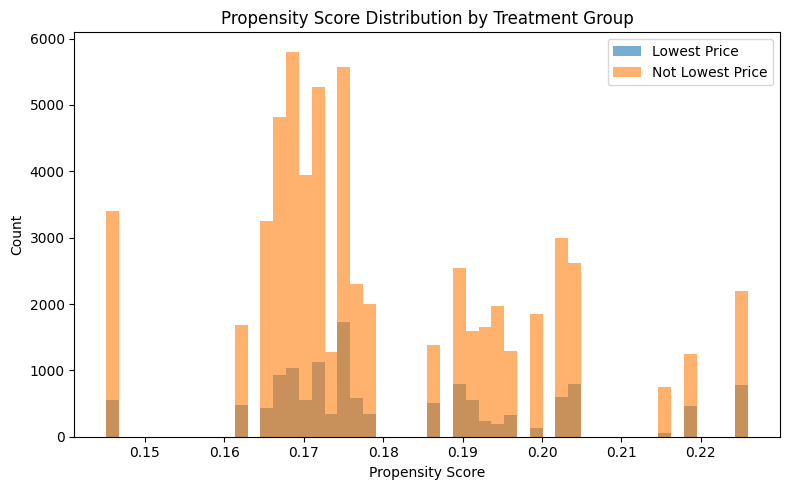

In [8]:


treated = df[df["is_lowest_price"] == 1]["propensity_score"]
control = df[df["is_lowest_price"] == 0]["propensity_score"]

plt.figure(figsize=(8,5))

plt.hist(treated, bins=50, alpha=0.6, label="Lowest Price")
plt.hist(control, bins=50, alpha=0.6, label="Not Lowest Price")

plt.title("Propensity Score Distribution by Treatment Group")
plt.xlabel("Propensity Score")
plt.ylabel("Count")
plt.legend()

plt.tight_layout()
plt.show()

In [9]:
# create weight to balance the data  

df["weight"] = (
    df["is_lowest_price"] / df["propensity_score"]
    + (1 - df["is_lowest_price"]) / (1 - df["propensity_score"])
)

# estimate treatment effect (weighted)  

X_out = sm.add_constant(df[["is_lowest_price"]])
y_out = df["buy_box_winner"]

ipw_model = sm.GLM(
    y_out,
    X_out,
    family=sm.families.Binomial(),
    freq_weights=df["weight"]
).fit()

print(ipw_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:         buy_box_winner   No. Observations:                74970
Model:                            GLM   Df Residuals:                149937.09
Model Family:                Binomial   Df Model:                            1
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -70942.
Date:                Fri, 20 Mar 2026   Deviance:                   1.4188e+05
Time:                        13:07:08   Pearson chi2:                 1.50e+05
No. Iterations:                     5   Pseudo R-squ. (CS):             0.5048
Covariance Type:            nonrobust                                         
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -2.4162      0.013   -1

In [10]:
import numpy as np
import pandas as pd

features = ["shipping_days", "seller_rating", "is_fba"]

balance_rows = []

for feature in features:
    
    # Before weighting
    treated_mean = df[df["is_lowest_price"] == 1][feature].mean()
    control_mean = df[df["is_lowest_price"] == 0][feature].mean()
    
    # After weighting
    treated_w = np.average(
        df[df["is_lowest_price"] == 1][feature],
        weights=df[df["is_lowest_price"] == 1]["weight"]
    )
    
    control_w = np.average(
        df[df["is_lowest_price"] == 0][feature],
        weights=df[df["is_lowest_price"] == 0]["weight"]
    )
    
    balance_rows.append({
        "feature": feature,
        "treated_mean_before": treated_mean,
        "control_mean_before": control_mean,
        "treated_mean_after": treated_w,
        "control_mean_after": control_w
    })

balance_df = pd.DataFrame(balance_rows)
balance_df

,feature,treated_mean_before,control_mean_before,treated_mean_after,control_mean_after
0,shipping_days,2.393599,2.490471,2.464564,2.472558
1,seller_rating,91.551837,91.664950,91.649418,91.644920
2,is_fba,0.716609,0.712309,0.715949,0.713244


In [11]:
balance_df["diff_before"] = (
    balance_df["treated_mean_before"] - balance_df["control_mean_before"]
)

balance_df["diff_after"] = (
    balance_df["treated_mean_after"] - balance_df["control_mean_after"]
)

balance_df

,feature,treated_mean_before,control_mean_before,treated_mean_after,control_mean_after,diff_before,diff_after
0,shipping_days,2.393599,2.490471,2.464564,2.472558,-0.096872,-0.007994
1,seller_rating,91.551837,91.664950,91.649418,91.644920,-0.113113,0.004498
2,is_fba,0.716609,0.712309,0.715949,0.713244,0.004299,0.002706


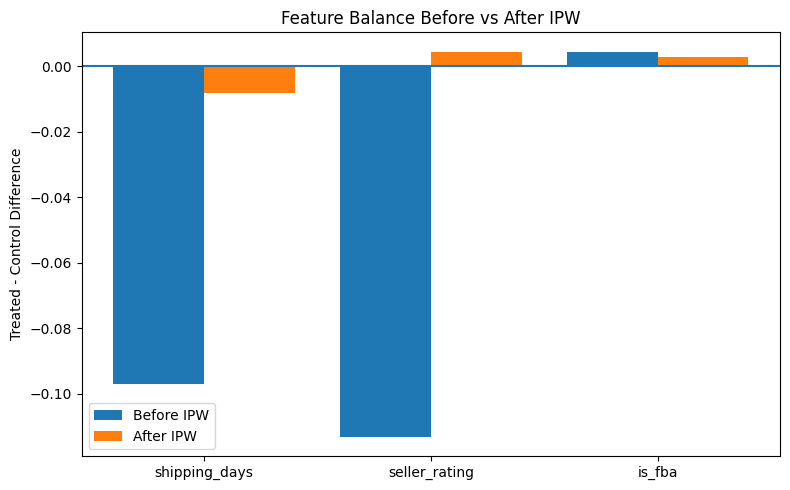

In [12]:
import matplotlib.pyplot as plt

x = range(len(balance_df))

plt.figure(figsize=(8,5))

plt.bar(x, balance_df["diff_before"], width=0.4, label="Before IPW")
plt.bar(
    [i + 0.4 for i in x],
    balance_df["diff_after"],
    width=0.4,
    label="After IPW"
)

plt.xticks([i + 0.2 for i in x], balance_df["feature"])
plt.axhline(0)
plt.title("Feature Balance Before vs After IPW")
plt.ylabel("Treated - Control Difference")
plt.legend()

plt.tight_layout()
plt.show()

## Covariate Balance Check

To validate the effectiveness of inverse probability weighting, we compare feature distributions between treated and control groups before and after weighting.

Prior to weighting, treated and control groups differ across key variables such as shipping speed, seller rating, and fulfillment type.

After applying IPW, these differences are substantially reduced, indicating that the reweighted sample achieves balance across observed covariates.

This supports the validity of the IPW-based causal estimates.

## Causal Effect Comparison: Pricing → Buy Box Ownership

| Method        | Estimate Type        | Effect Size | Interpretation |
|--------------|---------------------|------------|----------------|
| Naive        | Probability → Odds  | ~161x      | Strongly overstated effect due to confounding (mixes price + seller quality + fulfillment advantages) |
| Regression   | Adjusted Odds Ratio | ~23x       | Controls for shipping, rating, and FBA; isolates cleaner causal effect of price |
| IPW          | Weighted Odds Ratio | ~18.5x     | Reweights data to simulate random assignment; confirms robust causal effect |

---

### Key Takeaways

- The naive estimate dramatically overstates the impact of pricing due to confounding factors  
- Both regression adjustment and IPW significantly reduce the estimated effect  
- The similarity between regression (~23x) and IPW (~18.5x) suggests a **robust causal relationship**  
- Pricing is the dominant driver of Buy Box ownership, but not the only factor  
- If the seller does not have the lowest price the odds of winning the Buy Box is ~8%

---

### One-Line Summary

After correcting for confounding, being the lowest priced seller increases the odds of winning the Buy Box by approximately **18–23x**, confirming a strong but not exclusive causal effect of pricing.  

---

## Balance Check Interpretation

Prior to weighting, treated and control groups differed across key covariates, particularly shipping speed and seller rating, indicating potential confounding.

After applying inverse probability weighting, these differences are substantially reduced and close to zero across all features. This indicates that the reweighted sample achieves strong covariate balance.

As a result, the IPW-adjusted estimates can be interpreted as a credible approximation of the causal effect of pricing on Buy Box ownership.  

---  



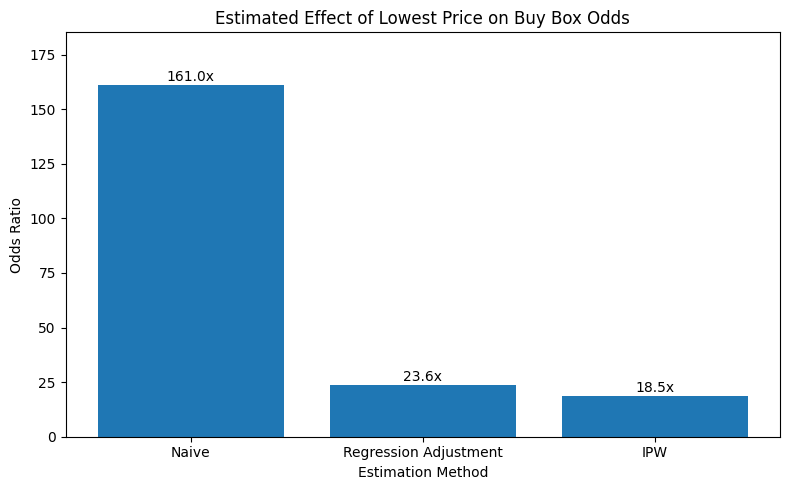

In [13]:
# Example values based on your results
naive_odds_ratio = 161.0
regression_odds_ratio = np.exp(3.1606)   # ~23.6
ipw_odds_ratio = np.exp(2.9167)          # ~18.5

comparison_df = pd.DataFrame({
    "method": ["Naive", "Regression Adjustment", "IPW"],
    "odds_ratio": [naive_odds_ratio, regression_odds_ratio, ipw_odds_ratio]
})

plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["method"], comparison_df["odds_ratio"])
plt.title("Estimated Effect of Lowest Price on Buy Box Odds")
plt.ylabel("Odds Ratio")
plt.xlabel("Estimation Method")

for bar, value in zip(bars, comparison_df["odds_ratio"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2,
        f"{value:.1f}x",
        ha="center"
    )

plt.ylim(0, max(comparison_df["odds_ratio"]) * 1.15)
plt.tight_layout()
plt.show()

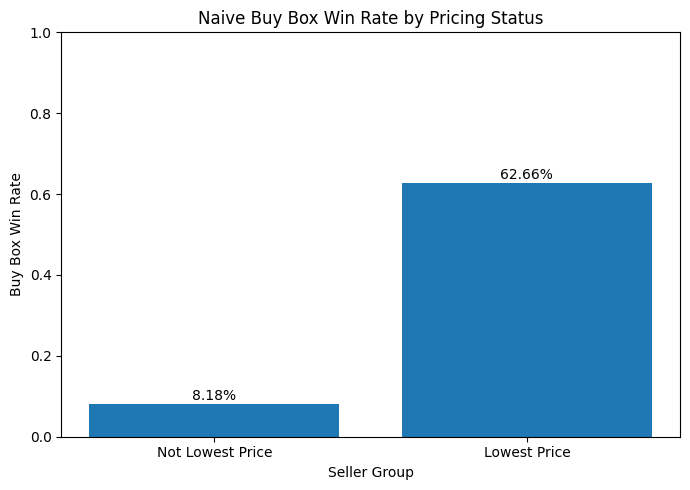

In [14]:
naive_prob = (
    df.groupby("is_lowest_price")["buy_box_winner"]
    .mean()
    .reset_index()
)

naive_prob["seller_type"] = naive_prob["is_lowest_price"].map({
    0: "Not Lowest Price",
    1: "Lowest Price"
})

plt.figure(figsize=(7, 5))
bars = plt.bar(naive_prob["seller_type"], naive_prob["buy_box_winner"])
plt.title("Naive Buy Box Win Rate by Pricing Status")
plt.ylabel("Buy Box Win Rate")
plt.xlabel("Seller Group")

for bar, value in zip(bars, naive_prob["buy_box_winner"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f"{value:.2%}",
        ha="center"
    )

plt.ylim(0, 1.0)
plt.tight_layout()
plt.show()

In [15]:
effect_table = pd.DataFrame({
    "Method": ["Naive", "Regression Adjustment", "IPW"],
    "Effect Type": ["Naive Odds Ratio", "Adjusted Odds Ratio", "Weighted Odds Ratio"],
    "Effect Size": [
        naive_odds_ratio,
        regression_odds_ratio,
        ipw_odds_ratio
    ]
})

effect_table["Effect Size"] = effect_table["Effect Size"].round(1)
effect_table

,Method,Effect Type,Effect Size
0,Naive,Naive Odds Ratio,161.0
1,Regression Adjustment,Adjusted Odds Ratio,23.6
2,IPW,Weighted Odds Ratio,18.5


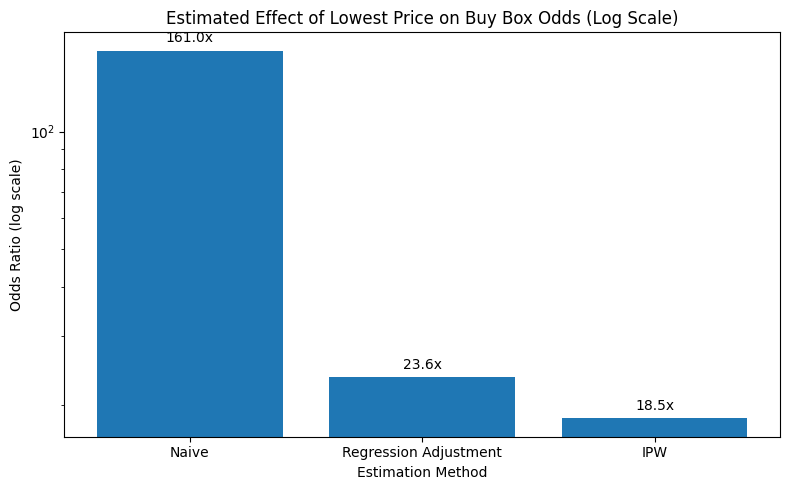

In [16]:
plt.figure(figsize=(8, 5))
bars = plt.bar(comparison_df["method"], comparison_df["odds_ratio"])
plt.yscale("log")
plt.title("Estimated Effect of Lowest Price on Buy Box Odds (Log Scale)")
plt.ylabel("Odds Ratio (log scale)")
plt.xlabel("Estimation Method")

for bar, value in zip(bars, comparison_df["odds_ratio"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value * 1.05,
        f"{value:.1f}x",
        ha="center"
    )

plt.tight_layout()
plt.show()

## Double Robust AIPW Model  

Combine estimate of propensity scores and estimate of outcomes into one estimator  

## Doubly Robust Estimation (AIPW)

To further strengthen the causal analysis, we implement an Augmented Inverse Probability Weighting (AIPW) estimator.

This approach combines:
- propensity score weighting (IPW)
- outcome regression models

The estimator is "doubly robust," meaning it remains consistent if either the propensity model or the outcome model is correctly specified.

The AIPW estimate of the treatment effect is consistent with both the regression-adjusted and IPW results, providing additional confidence that pricing has a strong causal impact on Buy Box outcomes.

In [17]:
p = df['propensity_score']
t = df['is_lowest_price']
y = df['buy_box_winner']

In [18]:
# outcome models

# treated model   
df_t = df[df['is_lowest_price'] == 1]
X_t = sm.add_constant(df_t[features])
y_t = df_t['buy_box_winner']

model_t = sm.Logit(y_t, X_t).fit(disp=0)

#control model 
df_c = df[df['is_lowest_price']==0]
X_c = sm.add_constant(df_c[features])
y_c = df_c['buy_box_winner']

model_c = sm.Logit(y_c, X_c).fit(disp=0)

In [19]:
# pridect couinterfactal for all rows  

X_all = sm.add_constant(df[features])

mu1 = model_t.predict(X_all)
mu0 = model_c.predict(X_all)

In [20]:
# AIPW Forumla  

aipw = (
    mu1 - mu0
    + t * (y - mu1) / p
    - (1 - t) * (y - mu0) / (1 - p)
)

ate_aipw = aipw.mean()
ate_aipw

0.5395498517145989

In [21]:
results_compare = pd.DataFrame({
    "Method": ["Naive", "Regression (Logit)", "IPW", "AIPW"],
    "Metric": [
        "Difference in probability",
        "Odds ratio",
        "Odds ratio",
        "Probability difference"
    ],
    "Estimate": [
        naive_odds_ratio,
        np.exp(3.1606),
        np.exp(2.9167),
        ate_aipw
    ]
})

results_compare

,Method,Metric,Estimate
0,Naive,Difference in probability,161.000000
1,Regression (Logit),Odds ratio,23.584743
2,IPW,Odds ratio,18.480202
3,AIPW,Probability difference,0.539550


## Causal Effect Comparison: Pricing → Buy Box Ownership

| Method        | Metric                     | Estimate | Interpretation |
|--------------|--------------------------|----------|----------------|
| Naive        | Odds Ratio               | ~161x    | Strongly overstated due to confounding |
| Regression   | Adjusted Odds Ratio      | ~23.6x   | Controls for observed differences |
| IPW          | Weighted Odds Ratio      | ~18.5x   | Balances treatment assignment |
| AIPW         | Probability Difference   | +0.54    | ~54pp increase in Buy Box win probability |

---

### Key Takeaways

- The naive estimate significantly overstates the effect of pricing  
- Both regression and IPW produce consistent, lower estimates  
- AIPW confirms the effect and translates it into a business-relevant metric  
- Pricing has a strong and robust causal impact, increasing Buy Box probability by ~54 percentage points  
- This answers "What do I gain by lowering price?" => 54 percentage points  
  - Analysis -> Decision Science  
- This gives you the increased PROBABILITY of winning the Buy Box with having the lowest price, BUT we still need to understand if lowering the price increases PROFIT (business question)  
    - We estimated: "Does lowest price increase win probability?" => yes, by 54 percentage points 
    - We still need to estimate: "Does lowering price increase PROFIT" ~ main business question


        "After correcting for confounding, being the lowest priced seller increases the probability of winning the Buy Box by approximately 50–55 percentage points, confirming that pricing is the dominant driver of marketplace outcomes."